In [1]:
import catalogue_analysis as ca
import numpy as np
from astropy.table import join,Table,Column,vstack
from astropy.io import fits


In [2]:

hdul = fits.open("GbandLF.fits")

hdu_names = [hdu.name for hdu in hdul]
print('Tables contained in file:',hdu_names[1:])


LFS=Table(hdul["LFS"].data)
LFN=Table(hdul["LFN"].data)
LFSDQ1=Table(hdul["LFSDQ1"].data)
LFNDQ1=Table(hdul["LFNDQ1"].data)
LFSDQ2=Table(hdul["LFSDQ2"].data)
LFNDQ2=Table(hdul["LFNDQ2"].data)


Tables contained in file: ['LFS', 'LFN', 'LFSDQ2', 'LFNDQ2', 'LFSDQ1', 'LFNDQ1']


['mag', 'logphi', 'logphi_low', 'logphi_hi']


NameError: name 'bin_cen' is not defined

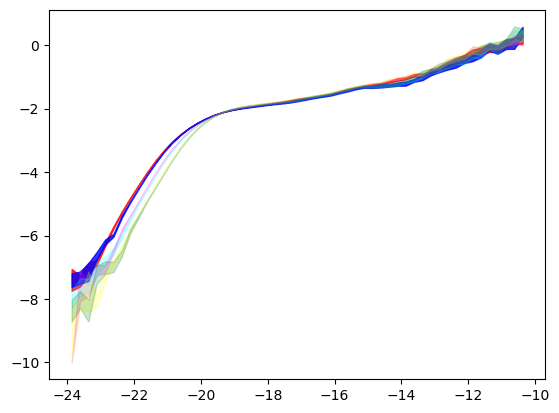

In [3]:
# plot each LF
import matplotlib.pyplot as plt



print(LFS.colnames)


        
       
plt.fill_between(LFS['mag'],LFS['logphi_low'],LFS['logphi_hi'], color='red',alpha=0.8,label='S default')
plt.fill_between(LFN['mag'],LFN['logphi_low'],LFN['logphi_hi'], color='blue',alpha=0.8,label='N default')

plt.fill_between(LFSDQ1['mag'],LFSDQ1['logphi_low'],LFSDQ1['logphi_hi'], color='magenta',alpha=0.2,label='S DQ=1')
plt.fill_between(LFNDQ1['mag'],LFNDQ1['logphi_low'],LFNDQ1['logphi_hi'], color='cyan',alpha=0.2,label='N DQ=1')

plt.fill_between(LFSDQ2['mag'],LFSDQ2['logphi_low'],LFSDQ2['logphi_hi'], color='yellow',alpha=0.2,label='S DQ=2')
plt.fill_between(LFNDQ2['mag'],LFNDQ2['logphi_low'],LFNDQ2['logphi_hi'], color='green',alpha=0.2,label='N DQ=2')


# Reference Schechter function from Sam's draft paper Table 1
phi_star=10.0**(-2.14)
alpha=-1.39
mstar=-20.43
l_lstar= 10.0**(0.4*(-bin_cen+mstar))
phi_sch= phi_star * l_lstar**(1.0+alpha) * np.exp(-l_lstar) *(np.log(10.0)/2.5)
log_phi_sch = np.log10(phi_sch)
        
plt.plot(bin_cen,log_phi_sch, label='Reference Schechter Function')
plt.xlabel('$M_g - 5 log h$')
plt.ylabel('$log_{10} \phi(M_r)\quad  [mag^{-1} (Mpc/h)^{-3}]$')
plt.xlim([-26,-7.5])
plt.ylim([-7,1.0])
plt.legend()
plt.show()